# Trace Count v16_3: data first, three-character query second

This revision copies the complete v16.2 RoPE training and analysis pipeline while
changing one controlled factor: both nonthinking and thinking task sequences place
the full Shakespeare data window before the `<CountChar> ... <Sep>` query. It retains
fixed train/validation/test suites, live Drive checkpoints, resumable training,
checkpoint dynamics, final result export, and optional automatic runtime disconnect.

## 1. Mount Google Drive first

In [1]:
from pathlib import Path

# Match v16/v16.1: Drive stores checkpoints and result bundles only.
# Source code is cloned to the fast Colab-local filesystem in the next cell.
DRIVE_RESULTS_ROOT = Path(
    "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/"
    "Synthetic_CoT_NiaH_Count/colab_results"
)
DRIVE_READY = False
if Path("/content").exists():
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    DRIVE_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    DRIVE_READY = True
    print("Drive ready:", DRIVE_RESULTS_ROOT)
else:
    print("Local runtime: Drive mount skipped")

Drive ready: /content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results


## 2. Repository and environment

In [2]:
import os
import signal
import subprocess
import sys
import time
from pathlib import Path

setup_started = time.perf_counter()
assert DRIVE_READY, "Run the Google Drive mount cell before environment setup"
DRIVE_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# Match v16/v16.1: clone or fast-forward the public repo on Colab's local disk.
REPO_URL = "https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git"
preferred = Path("/content/Synthetic_CoT_NiaH_Count")
candidates = [Path.cwd(), *Path.cwd().parents, preferred]
repo = next(
    (path.resolve() for path in candidates if (path / "pyproject.toml").exists()),
    None,
)
if repo is None:
    subprocess.run(["git", "clone", REPO_URL, str(preferred)], check=True)
    repo = preferred
elif Path("/content").exists() and (repo / ".git").exists():
    subprocess.run(
        ["git", "-C", str(repo), "pull", "--ff-only"],
        check=True,
    )
assert (repo / "src" / "synthetic_counting_v16_3").is_dir(), (
    f"The checked-out repository at {repo} does not contain v16.3. "
    "Confirm that the clone/pull reached the current origin/main."
)
os.chdir(repo)

# Use the same ABI repair used by v16 when a reused Colab runtime has an
# inconsistent NumPy/pandas/scientific stack.
scientific_probe = subprocess.run(
    [
        sys.executable,
        "-c",
        "import numpy,pandas,scipy,matplotlib,seaborn",
    ],
    capture_output=True,
    text=True,
)
if scientific_probe.returncode:
    print(scientific_probe.stderr[-2000:])
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
            "--force-reinstall", "numpy==1.26.4", "pandas==2.2.3",
            "scipy==1.13.1", "matplotlib==3.8.4", "seaborn==0.13.2",
        ],
        check=True,
    )
    if Path("/content").exists():
        os.kill(os.getpid(), signal.SIGKILL)
    raise RuntimeError(
        "Scientific ABI repaired. Reconnect and rerun all cells."
    )

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", "."],
    check=True,
)

# Editable-install .pth files are processed only when Python starts. Make the
# copied src-layout package importable in this already-running notebook kernel.
src_root = str(repo / "src")
if src_root not in sys.path:
    sys.path.insert(0, src_root)
os.environ["PYTHONPATH"] = src_root + os.pathsep + os.environ.get("PYTHONPATH", "")

import synthetic_counting_v16_3
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Markdown, display

package_path = Path(synthetic_counting_v16_3.__file__).resolve()
assert package_path.is_relative_to(Path(src_root)), (
    f"Notebook kernel imported stale package from {package_path}"
)
subprocess_package_path = Path(
    subprocess.check_output(
        [
            sys.executable,
            "-c",
            "import synthetic_counting_v16_3 as p; print(p.__file__)",
        ],
        text=True,
    ).strip()
).resolve()
assert subprocess_package_path.is_relative_to(Path(src_root)), (
    f"Subprocess imported stale package from {subprocess_package_path}"
)

corpus_path = (
    repo
    / "src"
    / "synthetic_counting_v11"
    / "resources"
    / "tiny_shakespeare"
    / "input.txt"
)
assert corpus_path.exists(), f"Tiny Shakespeare is missing: {corpus_path}"

def run_streaming(command):
    # Forward every available child-output chunk, including tqdm carriage returns.
    import codecs

    command = [str(part) for part in command]
    print("$", " ".join(command), flush=True)
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=0,
    )
    assert process.stdout is not None
    decoder = codecs.getincrementaldecoder("utf-8")(errors="replace")
    while True:
        chunk = os.read(process.stdout.fileno(), 4096)
        if not chunk:
            break
        print(decoder.decode(chunk), end="", flush=True)
    print(decoder.decode(b"", final=True), end="", flush=True)
    returncode = process.wait()
    if returncode:
        raise subprocess.CalledProcessError(returncode, command)

print({
    "repo": str(repo),
    "repo_url": REPO_URL,
    "drive_results": str(DRIVE_RESULTS_ROOT),
    "src_root": src_root,
    "kernel_package": str(package_path),
    "subprocess_package": str(subprocess_package_path),
    "corpus": str(corpus_path),
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "torch": torch.__version__,
    "cuda": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
})
print(f"Environment setup block: {time.perf_counter() - setup_started:.1f} seconds")

{'repo': '/content/Synthetic_CoT_NiaH_Count', 'repo_url': 'https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git', 'drive_results': '/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results', 'src_root': '/content/Synthetic_CoT_NiaH_Count/src', 'kernel_package': '/content/Synthetic_CoT_NiaH_Count/src/synthetic_counting_v16_3/__init__.py', 'subprocess_package': '/content/Synthetic_CoT_NiaH_Count/src/synthetic_counting_v16_3/__init__.py', 'corpus': '/content/Synthetic_CoT_NiaH_Count/src/synthetic_counting_v11/resources/tiny_shakespeare/input.txt', 'python': '3.12.13', 'numpy': '2.0.2', 'pandas': '2.2.2', 'torch': '2.11.0+cu128', 'cuda': True, 'gpu': 'NVIDIA A100-SXM4-40GB'}
Environment setup block: 13.9 seconds


In [3]:
RUN_TESTS = False  # optional developer preflight; not required for training
if RUN_TESTS:
    test_process = subprocess.run(
        [sys.executable, "-m", "pytest", "-q", "tests/test_synthetic_counting_v16_3.py"],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    print(test_process.stdout, end="")
    test_process.check_returncode()
else:
    print("Optional repository tests skipped; pipeline validation remains enabled.")

Optional repository tests skipped; pipeline validation remains enabled.


## 3. Easy-to-edit settings

In [4]:
VERSION = "v16_3"
SEQUENCE_LAYOUT = "data_then_query"  # fixed in v16.3: data window, then query, then output
PRESET = "main"                 # use "debug" for an end-to-end check
SEED = 1234
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TASK_OCCURRENCE_RATIO = 1.0      # reference run: every example is a counting task
COUNT_MAX_THRESHOLD = 10
WEIGHT_DECAY = 0.01              # AdamW decay on all trainable parameters; 0.0 disables it
FINAL_COUNT_LOSS_WEIGHT = 1.0    # >1 upweights the final numeric answer target
COT_TRACE_LOSS_WEIGHT = 1.0      # >1 upweights CoT trace indices and marker characters
RPE_max_update = False           # unused by the reference RoPE pair
RUN_ROPE_NONTHINKING = True
RUN_ROPE_THINKING = True
RUN_RPE_NONTHINKING = False      # optional ablation; not in the reference report
RUN_RPE_THINKING = False         # optional ablation; not in the reference report
MAX_TRAIN_STEPS = 10_000         # optimizer steps for each enabled model
MAX_STEPS_FOR_LANGUAGE_PRED = 1_500  # through this step use all-token LM loss; afterward train task output only
CHECKPOINT_EVERY_STEPS = 500      # save step 0, every N steps, the objective boundary, and the final step
EVAL_EXAMPLES_PER_COUNT = 50     # examples for each count; suite size = this value x COUNT_MAX_THRESHOLD (reference: 500)
NEEDLE_POOL_SIZE = 100
NEEDLE_POOL_FREQUENCY_THRESHOLD = 0.04
OUT_ROOT = "runs/synthetic_counting_v16_3"
RUN_NAME = None                  # default name records all important settings
SKIP_COMPLETED = True
AUTO_DISCONNECT = True           # after the final Drive copy succeeds
DISCONNECT_DELAY_SECONDS = 10    # leave a short window for the final save message
CHECKPOINT_SYNC_ROOT = (
    DRIVE_RESULTS_ROOT / "v16_3_live_checkpoints" if DRIVE_READY else None
)

ENABLED_MODEL_VARIANTS = tuple(
    variant
    for enabled, variant in (
        (RUN_ROPE_NONTHINKING, "rope/nonthinking"),
        (RUN_ROPE_THINKING, "rope/thinking"),
        (RUN_RPE_NONTHINKING, "rpe/nonthinking"),
        (RUN_RPE_THINKING, "rpe/thinking"),
    )
    if enabled
)
if not ENABLED_MODEL_VARIANTS:
    raise ValueError("Enable at least one model variant")

from synthetic_counting_v16_3.config import preset_config
PLANNED_CONFIG = preset_config(
    PRESET,
    seed=SEED,
    device=DEVICE,
    task_occurrence_ratio=TASK_OCCURRENCE_RATIO,
    count_max_threshold=COUNT_MAX_THRESHOLD,
    weight_decay=WEIGHT_DECAY,
    final_count_loss_weight=FINAL_COUNT_LOSS_WEIGHT,
    cot_trace_loss_weight=COT_TRACE_LOSS_WEIGHT,
    rpe_max_update=RPE_max_update,
    enabled_model_variants=ENABLED_MODEL_VARIANTS,
    train_steps=MAX_TRAIN_STEPS,
    max_steps_for_language_pred=MAX_STEPS_FOR_LANGUAGE_PRED,
    checkpoint_every=CHECKPOINT_EVERY_STEPS,
    eval_examples_per_count=EVAL_EXAMPLES_PER_COUNT,
    needle_pool_size=NEEDLE_POOL_SIZE,
    needle_pool_frequency_threshold=NEEDLE_POOL_FREQUENCY_THRESHOLD,
)
assert PLANNED_CONFIG.sequence_layout == SEQUENCE_LAYOUT
EVAL_EXAMPLES_PER_SUITE = EVAL_EXAMPLES_PER_COUNT * COUNT_MAX_THRESHOLD
PERIODIC_TF_EXAMPLES_PER_MODEL = 7 * EVAL_EXAMPLES_PER_SUITE
LANGUAGE_PREDICTION_STEPS = min(MAX_STEPS_FOR_LANGUAGE_PRED, MAX_TRAIN_STEPS)
TASK_OUTPUT_ONLY_STEPS = max(0, MAX_TRAIN_STEPS - MAX_STEPS_FOR_LANGUAGE_PRED)
PLANNED_CHECKPOINT_STEPS = sorted({
    0,
    *range(CHECKPOINT_EVERY_STEPS, MAX_TRAIN_STEPS + 1, CHECKPOINT_EVERY_STEPS),
    min(MAX_STEPS_FOR_LANGUAGE_PRED, MAX_TRAIN_STEPS),
    MAX_TRAIN_STEPS,
})
print({
    "config": PLANNED_CONFIG.to_dict(),
    "sequence_layout": PLANNED_CONFIG.sequence_layout,
    "sequence_templates": {
        "nonthinking": "<BOS> data[256] <CountChar> q1 q2 q3 <Sep> <Ans> count <EOS>",
        "thinking": "<BOS> data[256] <CountChar> q1 q2 q3 <Sep> <Think> trace </Think> <Ans> count <EOS>",
    },
    "enabled_model_variants": ENABLED_MODEL_VARIANTS,
    "number_of_models": len(ENABLED_MODEL_VARIANTS),
    "weight_decay": WEIGHT_DECAY,
    "rpe_max_update": RPE_max_update,
    "max_relative_distance": PLANNED_CONFIG.max_relative_distance,
    "language_prediction_steps": LANGUAGE_PREDICTION_STEPS,
    "task_output_only_steps": TASK_OUTPUT_ONLY_STEPS,
    "task_output_starts": {"nonthinking": "<Ans>", "thinking": "<Think>"},
    "max_steps_per_model": MAX_TRAIN_STEPS,
    "total_planned_optimizer_steps": len(ENABLED_MODEL_VARIANTS) * MAX_TRAIN_STEPS,
    "checkpoint_every_steps": CHECKPOINT_EVERY_STEPS,
    "planned_checkpoint_steps_per_model": PLANNED_CHECKPOINT_STEPS,
    "numeric_checkpoints_per_model": len(PLANNED_CHECKPOINT_STEPS),
    "eval_examples_per_suite": EVAL_EXAMPLES_PER_SUITE,
    "periodic_teacher_forced_examples_per_model": PERIODIC_TF_EXAMPLES_PER_MODEL,
})

{'config': {'version': 'v16_3', 'preset': 'main', 'seed': 1234, 'seq_len': 256, 'needle_set_size': 3, 'needle_pool_size': 100, 'needle_pool_frequency_threshold': 0.04, 'needle_pool_frequency_bins': 20, 'needle_pool_seed': None, 'count_max_threshold': 10, 'task_occurrence_ratio': 1.0, 'corpus_train_fraction': 0.8, 'corpus_validation_fraction': 0.1, 'candidate_filter_max_attempts': 100000, 'shuffle_needle_set_order': True, 'position_encodings': ['rope'], 'enabled_model_variants': ['rope/nonthinking', 'rope/thinking'], 'train_steps': 10000, 'batch_size': 128, 'lr': 0.0003, 'weight_decay': 0.01, 'adam_beta1': 0.9, 'adam_beta2': 0.999, 'warmup_steps': 500, 'grad_clip': 1.0, 'precision': 'float32', 'log_every': 50, 'eval_every': 500, 'ar_eval_every': 1000, 'checkpoint_every': 500, 'eval_examples_per_count': 50, 'ar_examples_per_count': 10, 'max_steps_for_language_pred': 1500, 'final_count_loss_weight': 1.0, 'cot_trace_loss_weight': 1.0, 'n_layer': 4, 'n_head': 4, 'n_embd': 256, 'n_inner': 10

## 4. Prepare split, pool, and fixed evaluation suites

$ /usr/bin/python3 -u -m synthetic_counting_v16_3.run_v16_3 --preset main --device cuda --seed 1234 --task-occurrence-ratio 1.0 --count-max-threshold 10 --weight-decay 0.01 --final-count-loss-weight 1.0 --cot-trace-loss-weight 1.0 --train-steps 10000 --max-steps-for-language-pred 1500 --checkpoint-every 500 --eval-examples-per-count 50 --needle-pool-size 100 --needle-pool-frequency-threshold 0.04 --out-root runs/synthetic_counting_v16_3 --no-rpe-max-update --model-variant rope/nonthinking --model-variant rope/thinking --checkpoint-sync-root /content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v16_3_live_checkpoints --skip-completed --stage prepare
[timing:start] scope=pipeline block=drive_restore
[timing:done] scope=pipeline block=drive_restore seconds=0.15 status=complete
[v16_3] stage=prepare
[timing:start] scope=pipeline block=prepare
[timing:done] scope=pipeline block=prepare seconds=0.49 status=complete
[timing:start] scope=pipeline block=driv

,set_id,frequency_sum,frequency_bin,character_1,codepoint_1,frequency_1,character_2,codepoint_2,frequency_2,character_3,codepoint_3,frequency_3
0,set_000,0.000129,0,$,36,0.000001,&,38,0.000003,X,88,0.000124
1,set_001,0.000996,0,J,74,0.000337,Z,90,0.000181,x,120,0.000478
2,set_002,0.001229,0,3,51,0.000030,V,86,0.000616,j,106,0.000583
3,set_003,0.001824,0,P,80,0.001090,Q,81,0.000257,x,120,0.000478
4,set_004,0.001978,0,!,33,0.001946,$,36,0.000001,3,51,0.000030
...,...,...,...,...,...,...,...,...,...,...,...,...
95,set_095,0.038534,19,',39,0.005655,H,72,0.002712,l,108,0.030167
96,set_096,0.038714,19,V,86,0.000616,d,100,0.028358,p,112,0.009740
97,set_097,0.038746,19,Z,90,0.000181,b,98,0.010207,d,100,0.028358
98,set_098,0.039594,19,3,51,0.000030,u,117,0.023810,w,119,0.015754


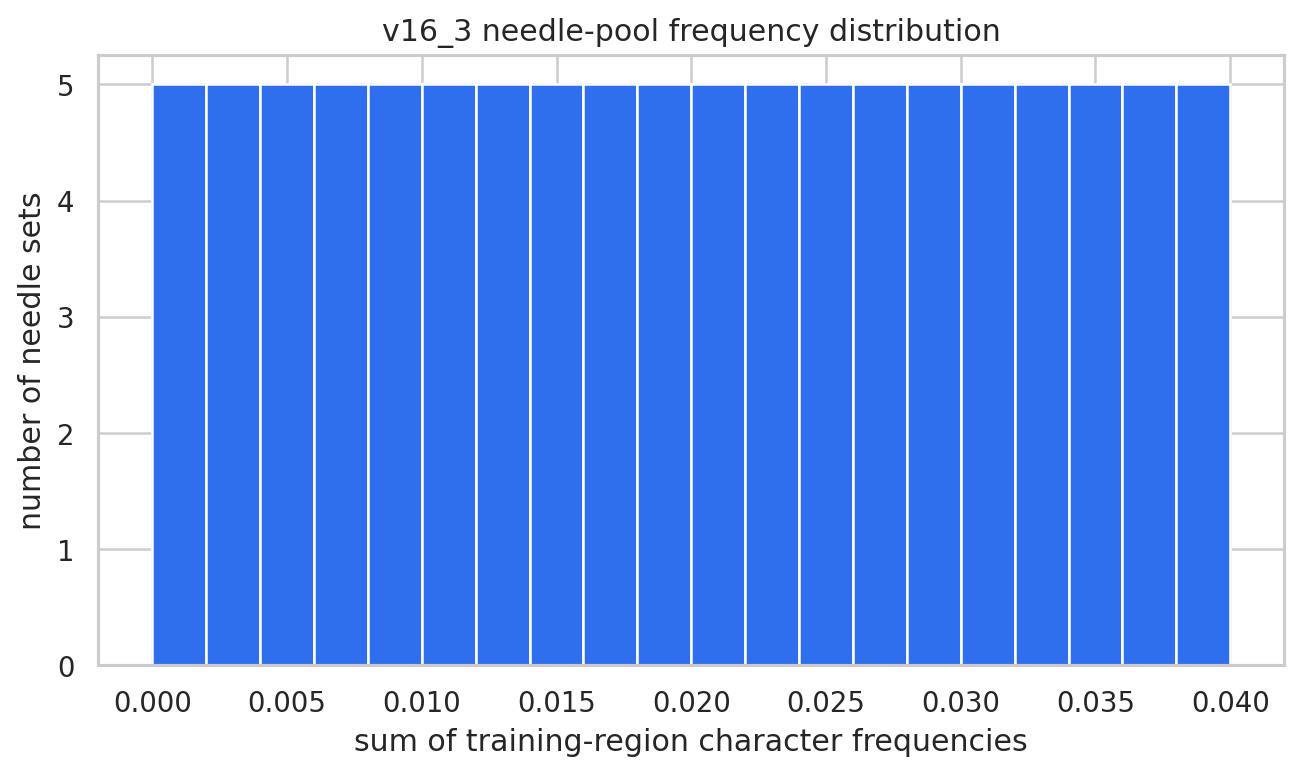

In [5]:
base_cmd = [
    sys.executable, "-u", "-m", "synthetic_counting_v16_3.run_v16_3",
    "--preset", PRESET,
    "--device", DEVICE,
    "--seed", str(SEED),
    "--task-occurrence-ratio", str(TASK_OCCURRENCE_RATIO),
    "--count-max-threshold", str(COUNT_MAX_THRESHOLD),
    "--weight-decay", str(WEIGHT_DECAY),
    "--final-count-loss-weight", str(FINAL_COUNT_LOSS_WEIGHT),
    "--cot-trace-loss-weight", str(COT_TRACE_LOSS_WEIGHT),
    "--train-steps", str(MAX_TRAIN_STEPS),
    "--max-steps-for-language-pred", str(MAX_STEPS_FOR_LANGUAGE_PRED),
    "--checkpoint-every", str(CHECKPOINT_EVERY_STEPS),
    "--eval-examples-per-count", str(EVAL_EXAMPLES_PER_COUNT),
    "--needle-pool-size", str(NEEDLE_POOL_SIZE),
    "--needle-pool-frequency-threshold", str(NEEDLE_POOL_FREQUENCY_THRESHOLD),
    "--out-root", OUT_ROOT,
]
base_cmd.append("--rpe-max-update" if RPE_max_update else "--no-rpe-max-update")
for variant in ENABLED_MODEL_VARIANTS:
    base_cmd += ["--model-variant", variant]
if RUN_NAME is not None:
    base_cmd += ["--run-name", RUN_NAME]
if CHECKPOINT_SYNC_ROOT is not None:
    base_cmd += ["--checkpoint-sync-root", str(CHECKPOINT_SYNC_ROOT)]
if SKIP_COMPLETED:
    base_cmd.append("--skip-completed")
prepare_started = time.perf_counter()
run_streaming([*base_cmd, "--stage", "prepare"])
print(f"Prepare block: {time.perf_counter() - prepare_started:.1f} seconds")

from synthetic_counting_v16_3.config import default_run_name
RUN_DIR = Path(OUT_ROOT) / (RUN_NAME or default_run_name(PLANNED_CONFIG))
display(pd.read_csv(RUN_DIR / "tables" / "needle_pool.csv"))
display(Image(filename=str(RUN_DIR / "figures" / "needle_pool_frequency_distribution.png")))

## 5. Train, analyze, and plot

In [6]:
training_started = time.perf_counter()
run_streaming([*base_cmd, "--stage", "train,attention,state,plots"])
print(f"Training/final-diagnostics block: {time.perf_counter() - training_started:.1f} seconds")
print("RUN_DIR =", RUN_DIR.resolve())

$ /usr/bin/python3 -u -m synthetic_counting_v16_3.run_v16_3 --preset main --device cuda --seed 1234 --task-occurrence-ratio 1.0 --count-max-threshold 10 --weight-decay 0.01 --final-count-loss-weight 1.0 --cot-trace-loss-weight 1.0 --train-steps 10000 --max-steps-for-language-pred 1500 --checkpoint-every 500 --eval-examples-per-count 50 --needle-pool-size 100 --needle-pool-frequency-threshold 0.04 --out-root runs/synthetic_counting_v16_3 --no-rpe-max-update --model-variant rope/nonthinking --model-variant rope/thinking --checkpoint-sync-root /content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v16_3_live_checkpoints --skip-completed --stage train,attention,state,plots
[timing:start] scope=pipeline block=drive_restore
[timing:done] scope=pipeline block=drive_restore seconds=0.16 status=complete
[v16_3] stage=train
[timing:start] scope=pipeline block=train
[train] rope/nonthinking
[resume] rope/nonthinking from step 500
v16_3 rope/nonthinking:  10%|▉ 

## 6. Analyze internal mechanisms across saved checkpoints

Checkpoint inventory: {'rope/nonthinking': [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000], 'rope/thinking': [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000]}
$ /usr/bin/python3 -u scripts/analyze_v16_3_checkpoint_dynamics.py runs/synthetic_counting_v16_3/v16_3_main_data-query_L256_pool100x3_pf0p04_count1-10_taskr1_wd0p01_fcw1_cotw1_langsteps1500_steps10000_ckpt500_evaln500_rope-nt-rope-t_allseq-taskout_seed1234 --device cuda --attention-examples-per-count 20 --ar-examples-per-count 10 --state-train-examples-per-count 40 --state-eval-examples-per-count 15
[dynamics:inventory] rope/nonthinking steps=[0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000]
[dynamics:inventory] rope/thinking steps=[0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 650

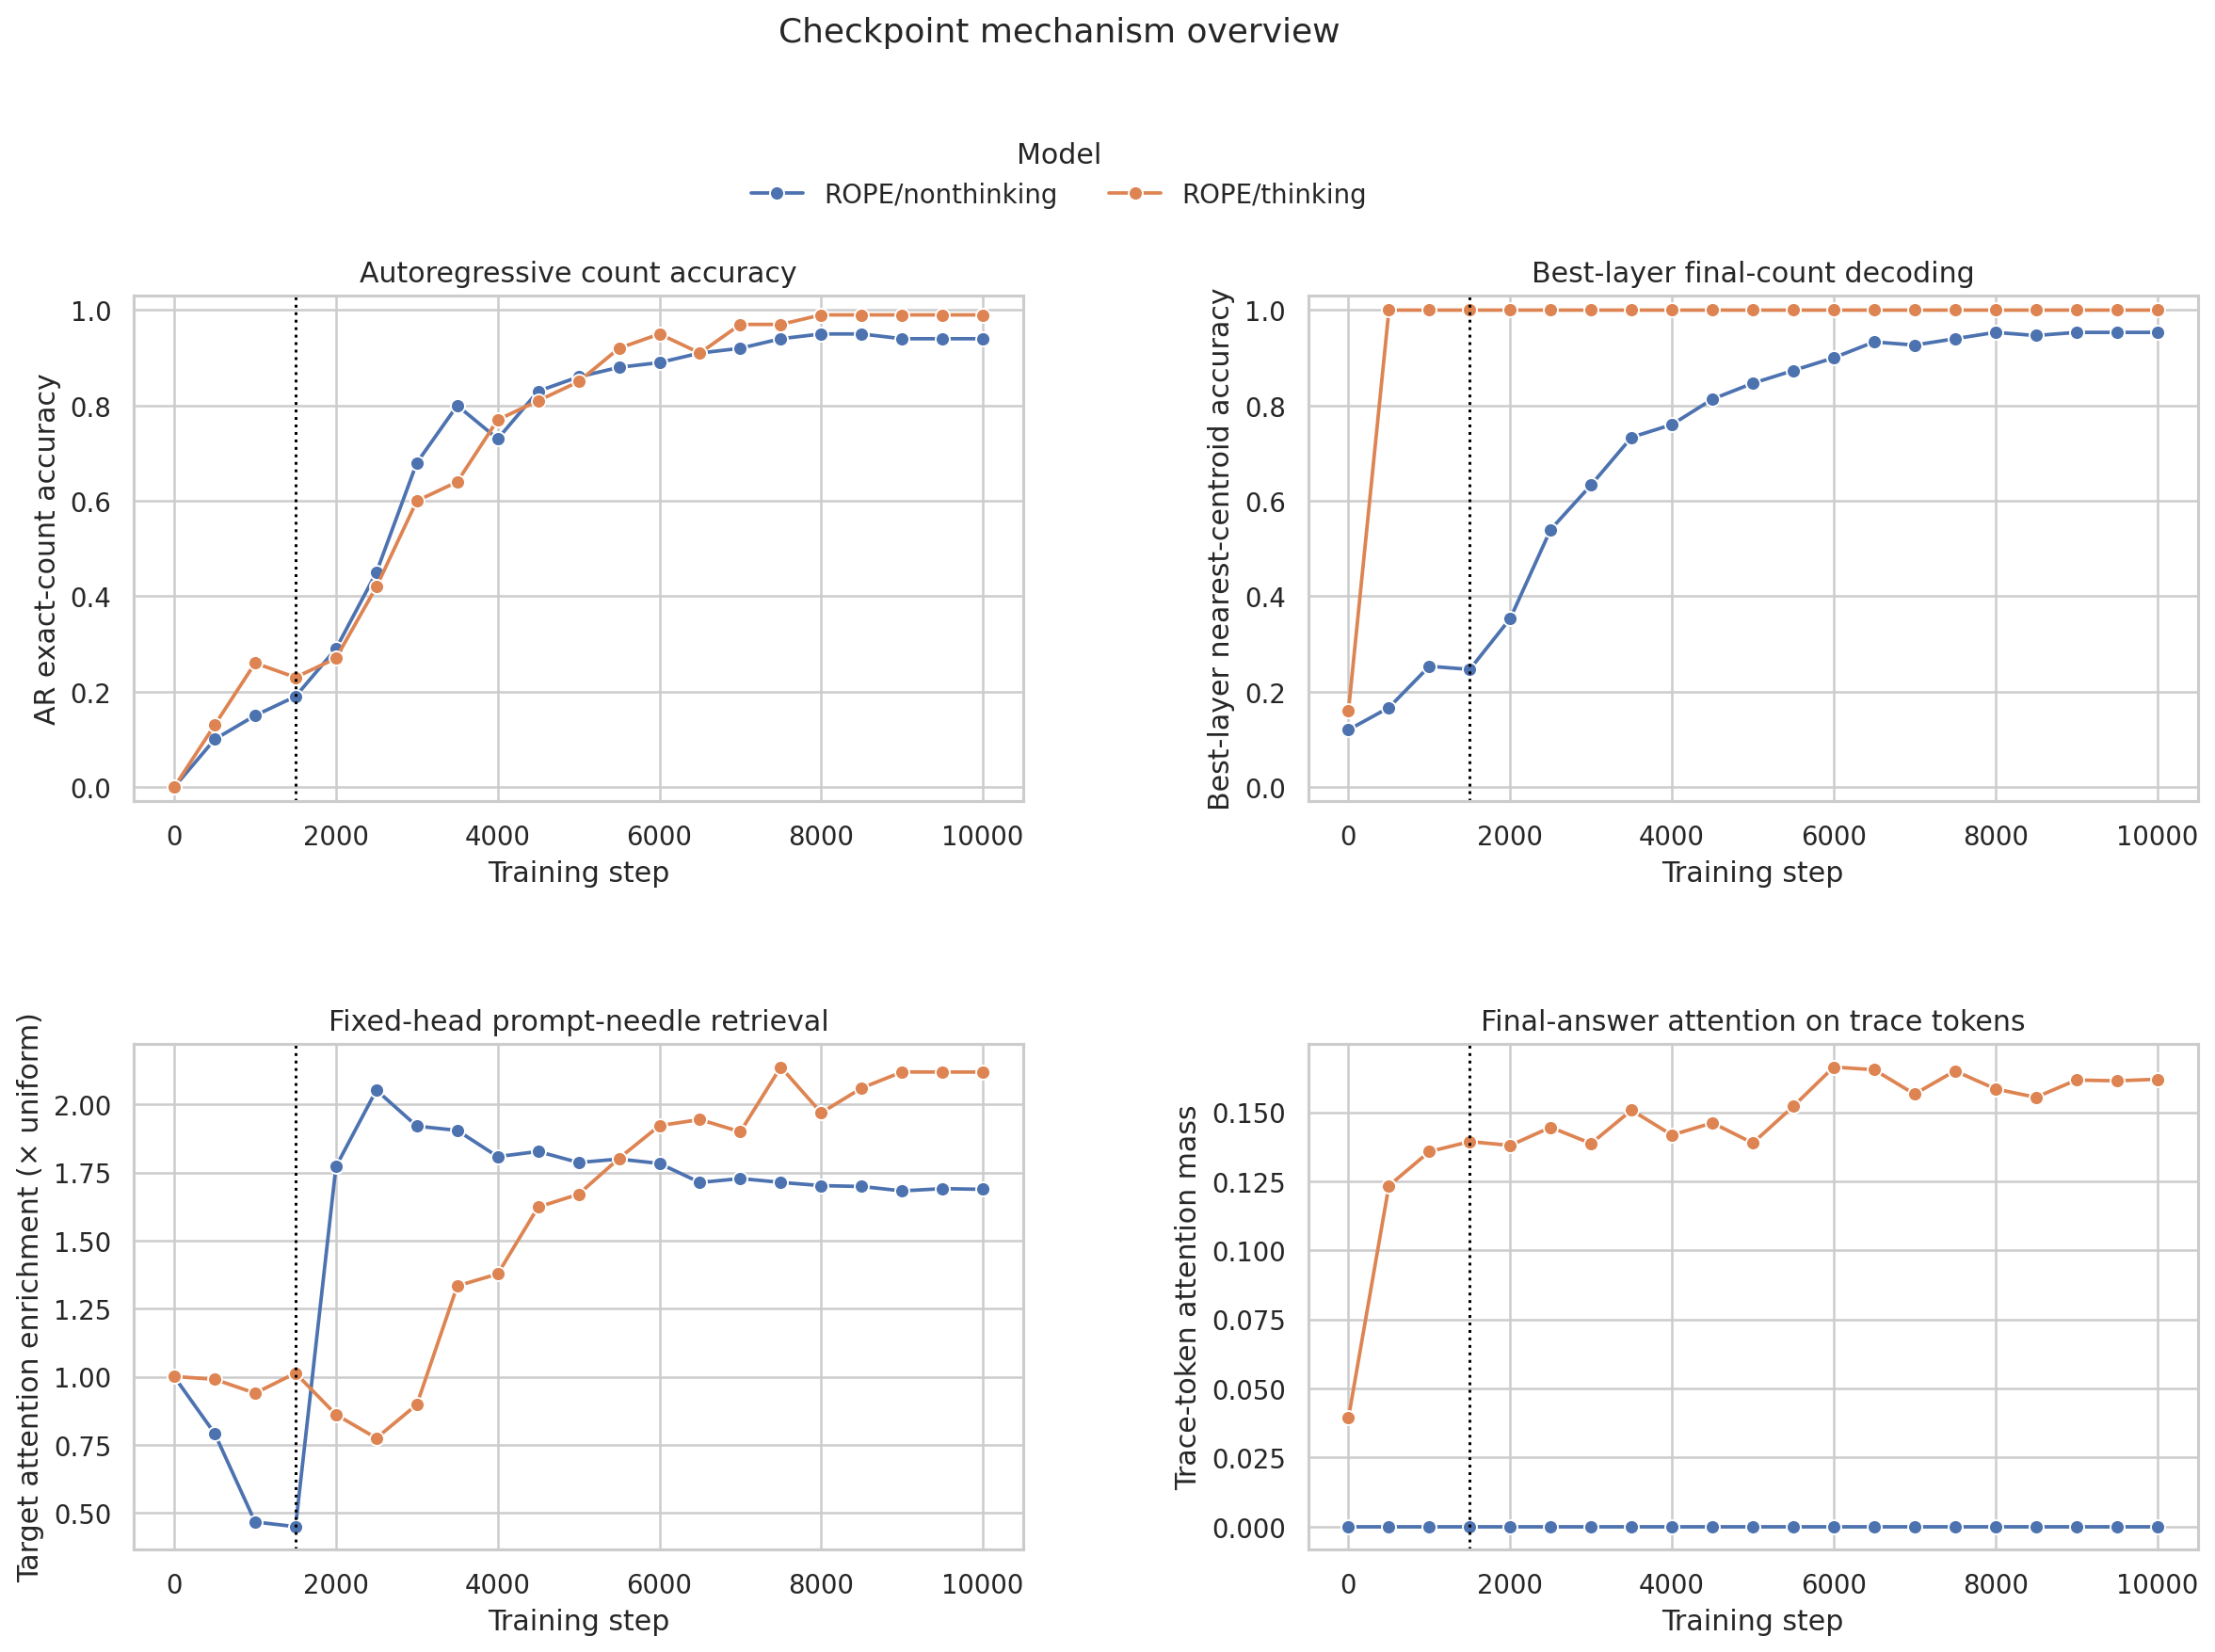

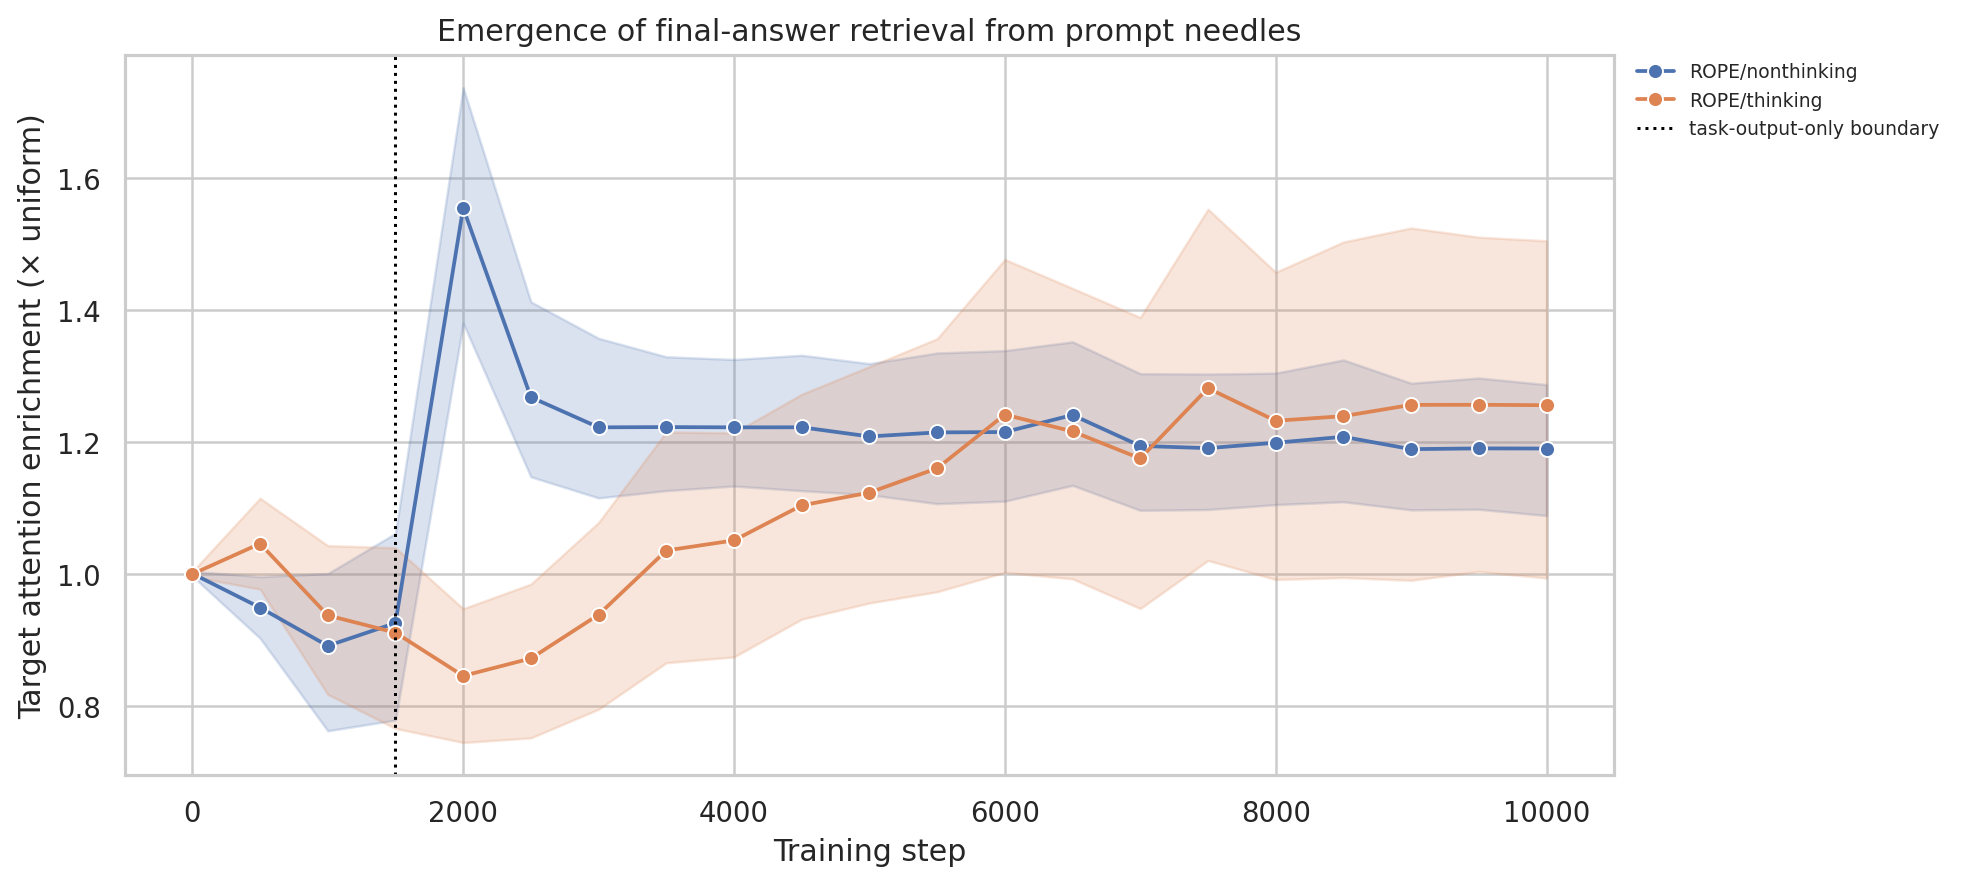

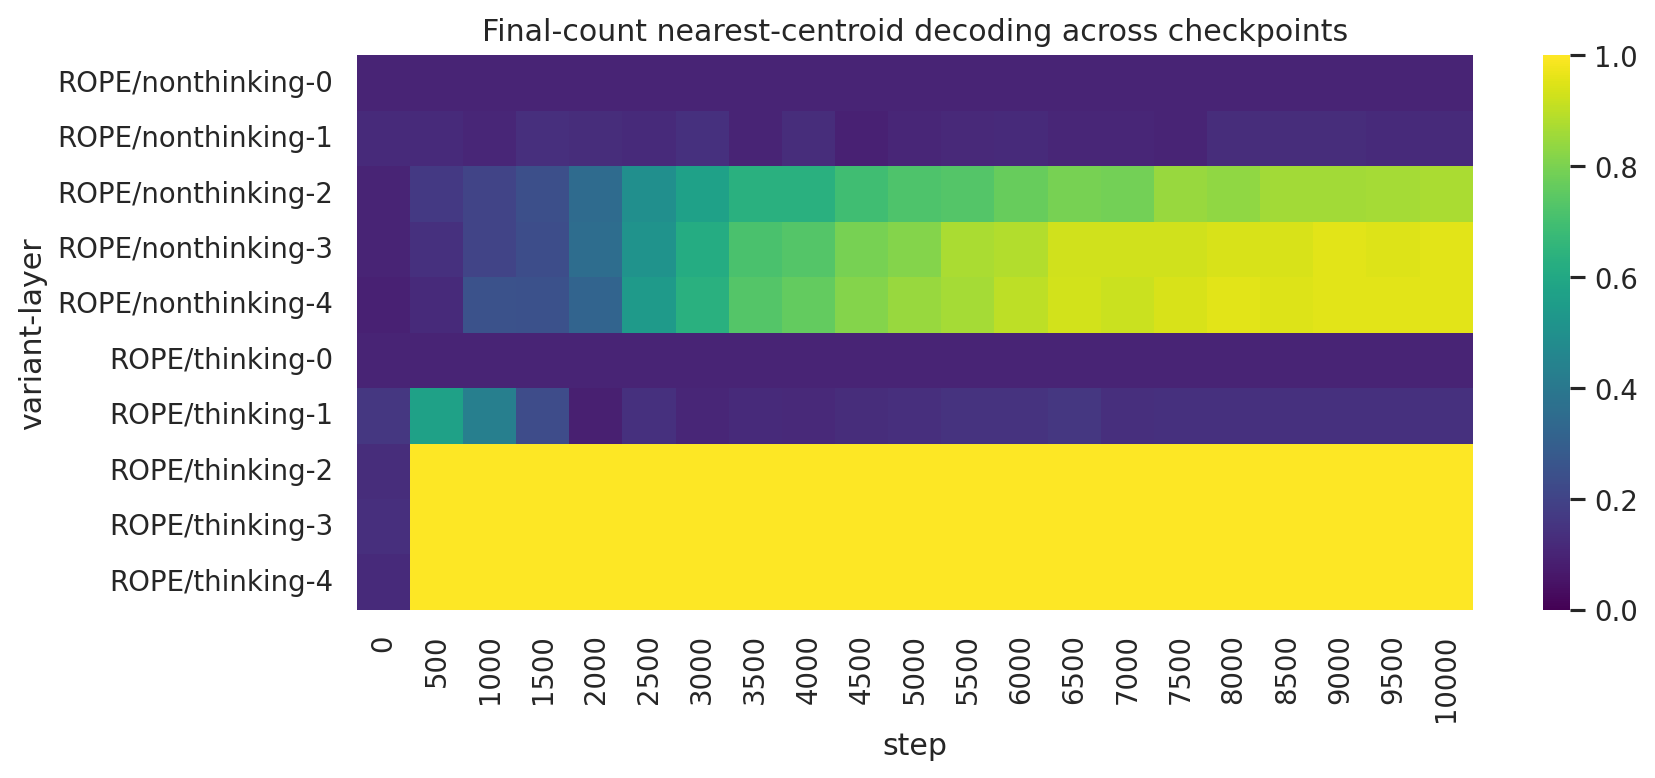

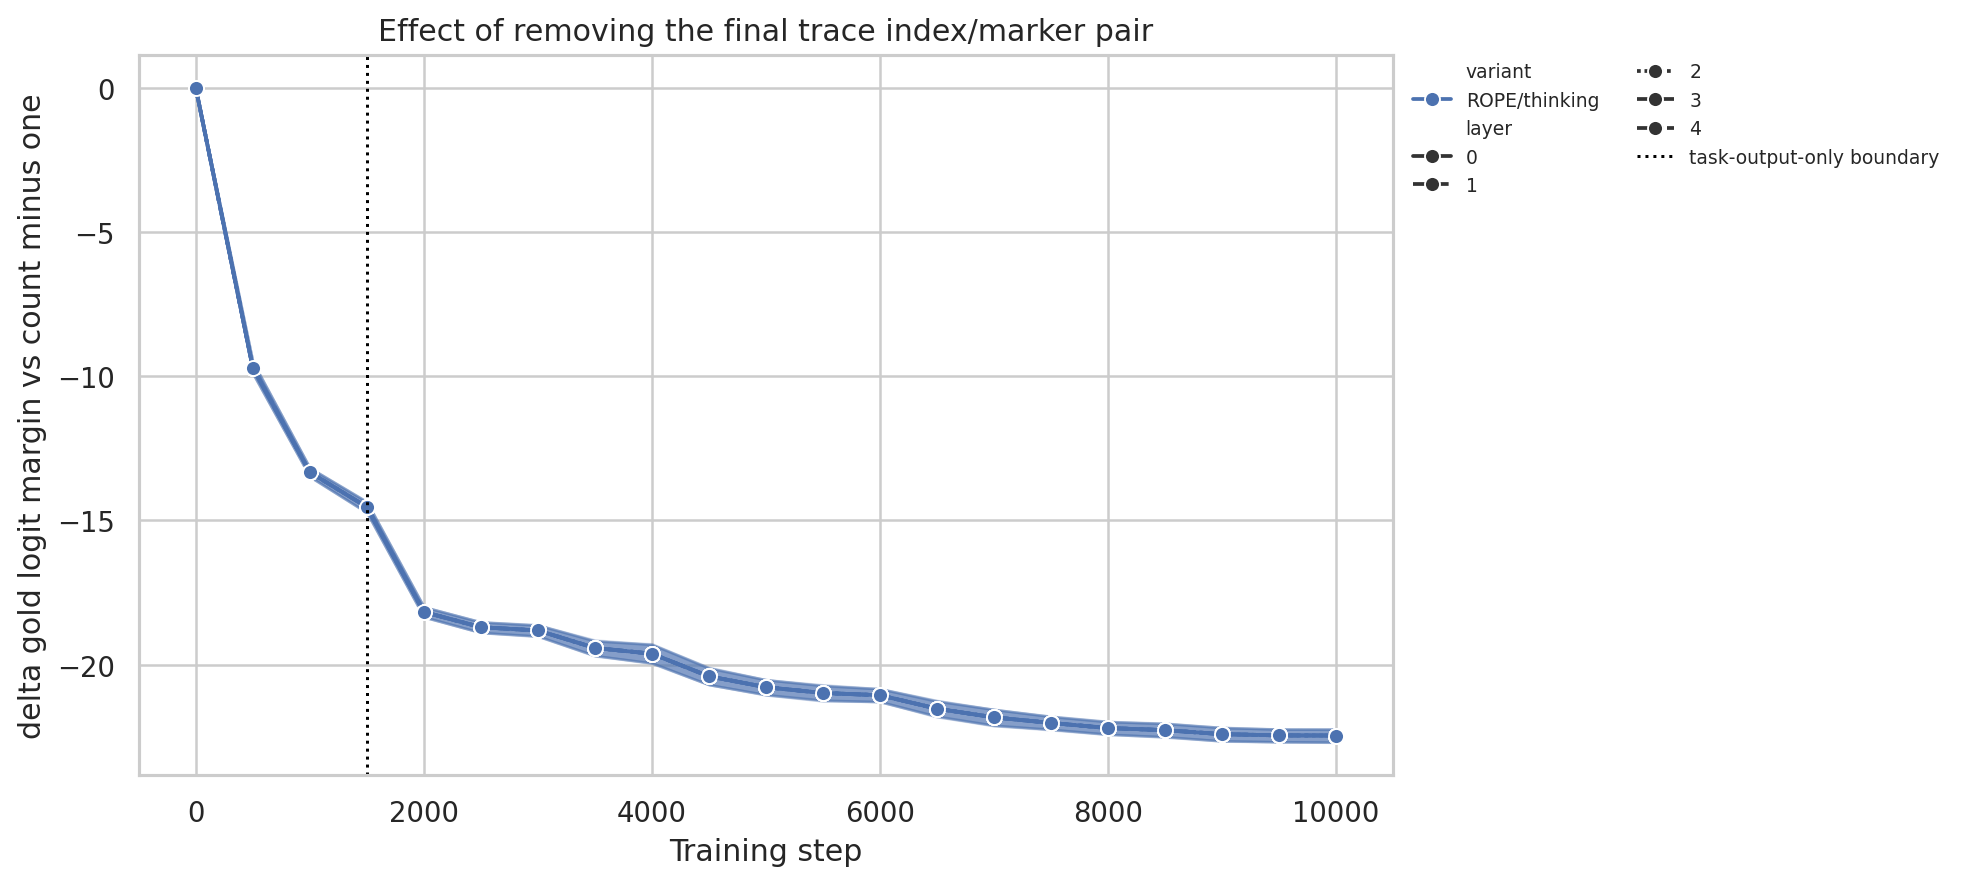

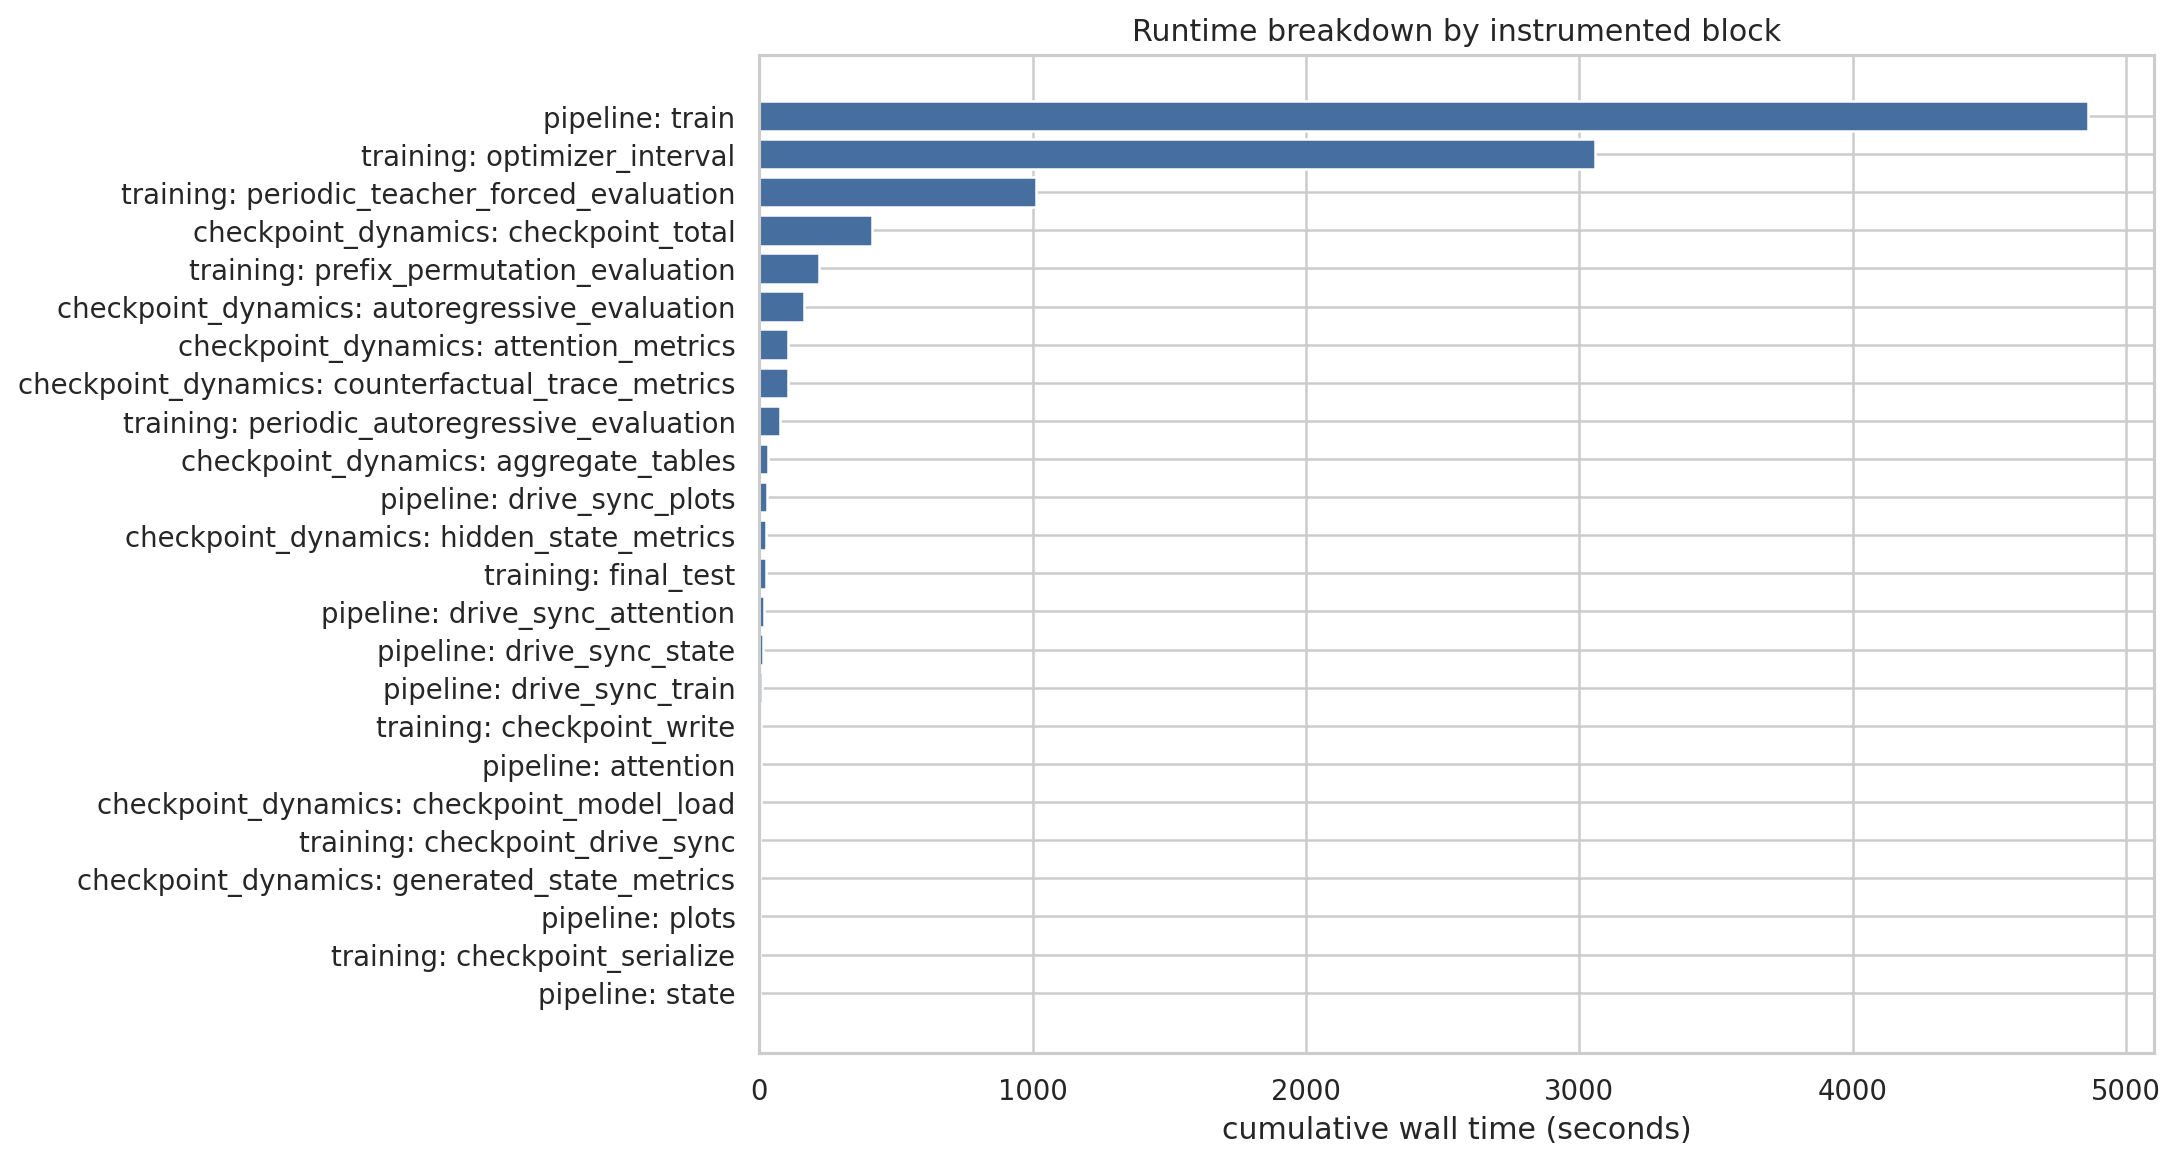

In [7]:
# Metric families are switchable, with explicit dependencies: CKA and
# counterfactual readouts require hidden-state collection. Defaults use fixed,
# count-balanced examples at every checkpoint for comparable trajectories.
RUN_CHECKPOINT_DYNAMICS = True
RUN_ATTENTION_DYNAMICS = True
RUN_HIDDEN_STATE_DYNAMICS = True
RUN_GENERATED_TRACE_DYNAMICS = True
RUN_COUNTERFACTUAL_DYNAMICS = True
RUN_REPRESENTATION_STABILITY = True
FORCE_CHECKPOINT_DYNAMICS = False  # False resumes completed checkpoint partitions

DYNAMICS_ATTENTION_EXAMPLES_PER_COUNT = 20  # 10 select heads + 10 held-out reporting examples
DYNAMICS_AR_EXAMPLES_PER_COUNT = 10         # autoregressive generations per true count
DYNAMICS_STATE_TRAIN_EXAMPLES_PER_COUNT = 40  # ridge/centroid fitting examples per count
DYNAMICS_STATE_EVAL_EXAMPLES_PER_COUNT = 15   # held-out state examples per count

if RUN_CHECKPOINT_DYNAMICS:
    from synthetic_counting_v16_3.training import checkpoint_steps

    checkpoint_inventory = {
        variant: [step for step, _ in checkpoint_steps(RUN_DIR, *variant.split("/"))]
        for variant in ENABLED_MODEL_VARIANTS
    }
    print("Checkpoint inventory:", checkpoint_inventory)
    required_steps = {min(MAX_STEPS_FOR_LANGUAGE_PRED, MAX_TRAIN_STEPS), MAX_TRAIN_STEPS}
    for variant, available_steps in checkpoint_inventory.items():
        missing = required_steps - set(available_steps)
        if missing:
            raise FileNotFoundError(
                f"{variant} is missing required checkpoint step(s) {sorted(missing)}; "
                "restore the run's checkpoints from Google Drive before analysis"
            )
    dynamics_cmd = [
        sys.executable, "-u", "scripts/analyze_v16_3_checkpoint_dynamics.py",
        str(RUN_DIR),
        "--device", DEVICE,
        "--attention-examples-per-count", str(DYNAMICS_ATTENTION_EXAMPLES_PER_COUNT),
        "--ar-examples-per-count", str(DYNAMICS_AR_EXAMPLES_PER_COUNT),
        "--state-train-examples-per-count", str(DYNAMICS_STATE_TRAIN_EXAMPLES_PER_COUNT),
        "--state-eval-examples-per-count", str(DYNAMICS_STATE_EVAL_EXAMPLES_PER_COUNT),
    ]
    for enabled, flag in (
        (RUN_ATTENTION_DYNAMICS, "--skip-attention"),
        (RUN_HIDDEN_STATE_DYNAMICS, "--skip-states"),
        (RUN_GENERATED_TRACE_DYNAMICS, "--skip-generated"),
        (RUN_COUNTERFACTUAL_DYNAMICS, "--skip-counterfactual"),
        (RUN_REPRESENTATION_STABILITY, "--skip-similarity"),
    ):
        if not enabled:
            dynamics_cmd.append(flag)
    if FORCE_CHECKPOINT_DYNAMICS:
        dynamics_cmd.append("--force")
    dynamics_started = time.perf_counter()
    run_streaming(dynamics_cmd)
    print(f"Checkpoint-dynamics block: {time.perf_counter() - dynamics_started:.1f} seconds")
    print("Dynamics manifest:", RUN_DIR / "analysis" / "checkpoint_dynamics" / "manifest.json")
    print("Detailed tables:", RUN_DIR / "tables" / "checkpoint_*.csv")
    for figure_name in (
        "checkpoint_mechanism_overview.png",
        "checkpoint_attention_retrieval_emergence.png",
        "checkpoint_final_count_probe_heatmap.png",
        "checkpoint_counterfactual_trace_readout.png",
        "runtime_breakdown.png",
    ):
        figure_path = RUN_DIR / "figures" / figure_name
        if figure_path.exists():
            display(Image(filename=str(figure_path)))
else:
    print("Checkpoint-dynamics analysis skipped; saved checkpoints remain available.")

## 7. Inspect train-versus-held-out loss curves

,step,position_encoding,mode,curve_source,source_region,suite,task_occurrence_ratio,realized_task_example_ratio,realized_task_token_ratio,num_examples,active_tokens,token_weighted_cross_entropy,example_mean_cross_entropy,token_weighted_perplexity,example_mean_perplexity
0,0,rope,nonthinking,heldout,validation,mixture,1.0,1.0,1.0,500,132000,4.451835,4.451835,85.784214,85.784214
1,0,rope,nonthinking,heldout,validation,raw,1.0,0.0,0.0,500,127500,4.452896,4.452896,85.875244,85.875244
2,0,rope,nonthinking,heldout,validation,task,1.0,1.0,1.0,500,132000,4.451835,4.451835,85.784214,85.784214
3,0,rope,nonthinking,train,train,mixture,1.0,1.0,1.0,500,132000,4.462828,4.462828,86.732428,86.732428
4,0,rope,nonthinking,train,train,raw,1.0,0.0,0.0,500,127500,4.464196,4.464196,86.851145,86.851145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,10000,rope,thinking,heldout,validation,raw,1.0,0.0,0.0,500,127500,5.702779,5.702779,299.699054,299.699054
248,10000,rope,thinking,heldout,validation,task,1.0,1.0,1.0,500,138500,5.294055,5.296007,199.149257,199.538421
249,10000,rope,thinking,train,train,mixture,1.0,1.0,1.0,500,138500,5.278243,5.280455,196.025252,196.459225
250,10000,rope,thinking,train,train,raw,1.0,0.0,0.0,500,127500,5.672617,5.672617,290.794566,290.794566


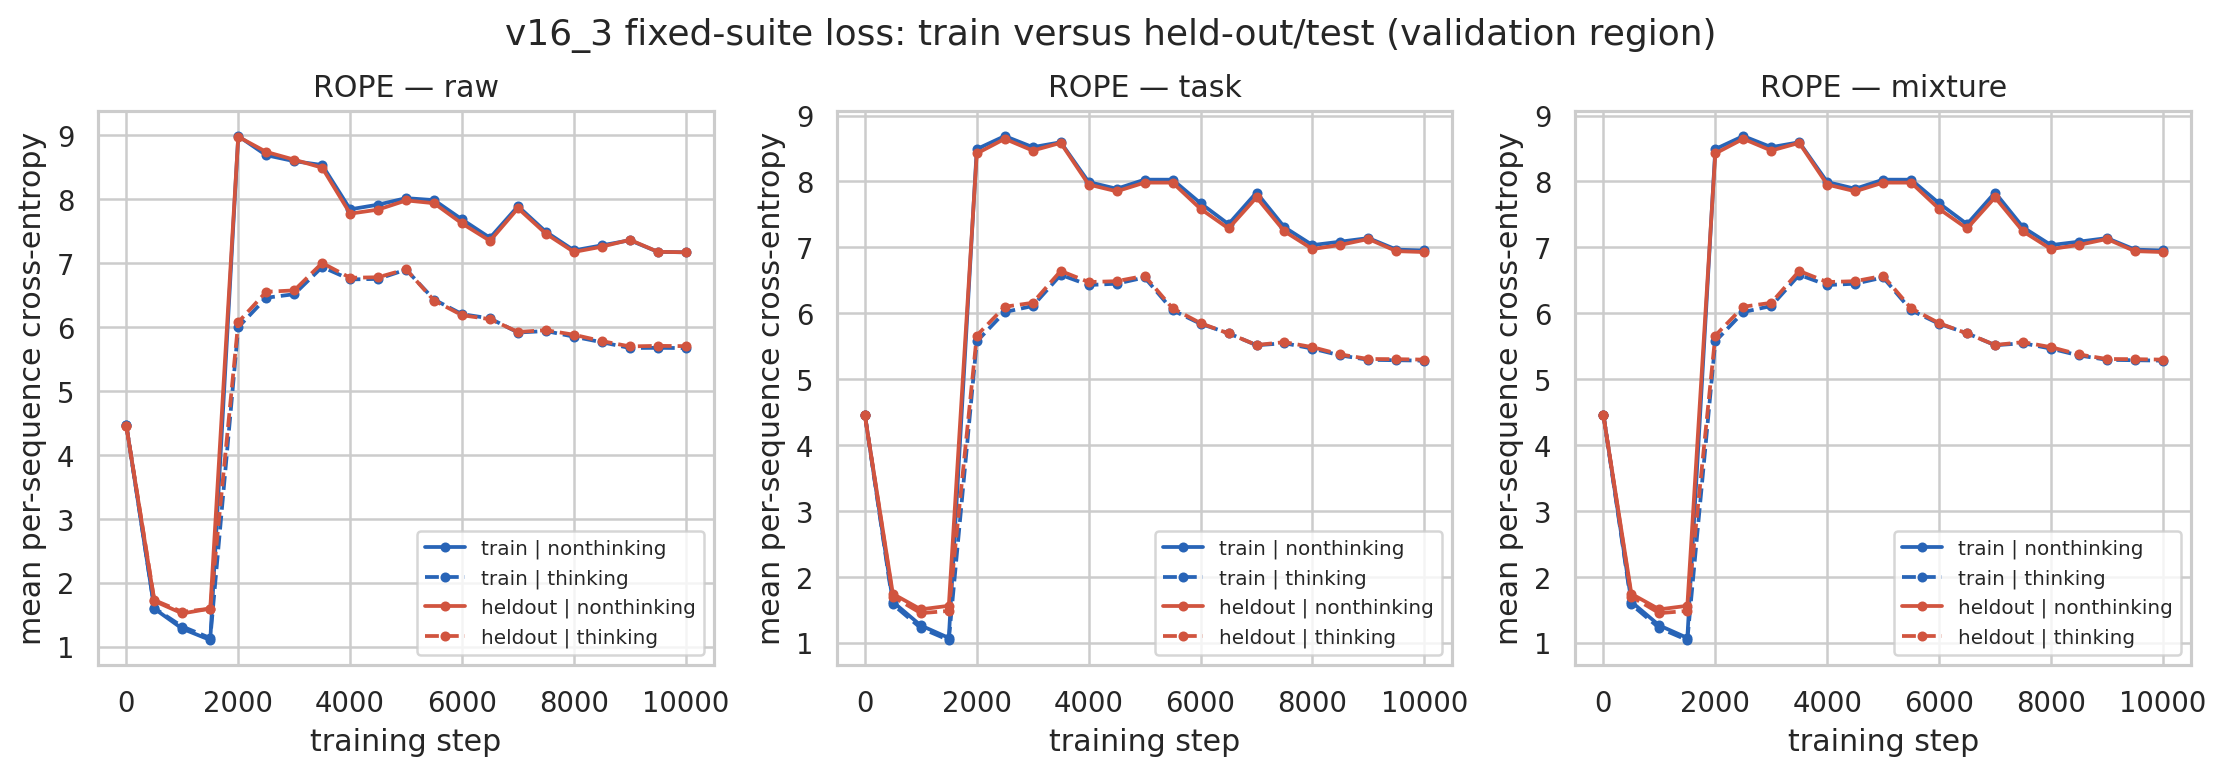

**Final-only untouched test results**

,step,position_encoding,mode,curve_source,source_region,suite,task_occurrence_ratio,realized_task_example_ratio,realized_task_token_ratio,num_examples,active_tokens,token_weighted_cross_entropy,example_mean_cross_entropy,token_weighted_perplexity,example_mean_perplexity
0,10000,rope,nonthinking,test,test,mixture,1.0,1.0,1.0,500,132000,6.820730,6.820730,916.653866,916.653866
1,10000,rope,nonthinking,test,test,raw,1.0,0.0,0.0,500,127500,7.064815,7.064815,1170.065904,1170.065904
2,10000,rope,nonthinking,test,test,task,1.0,1.0,1.0,500,132000,6.820730,6.820730,916.653866,916.653866
3,10000,rope,thinking,test,test,mixture,1.0,1.0,1.0,500,138500,5.252247,5.254357,190.994877,191.398463
4,10000,rope,thinking,test,test,raw,1.0,0.0,0.0,500,127500,5.664582,5.664582,288.467267,288.467267
5,10000,rope,thinking,test,test,task,1.0,1.0,1.0,500,138500,5.252247,5.254357,190.994877,191.398463


Result-display block: 0.0 seconds


In [8]:
inspect_started = time.perf_counter()
losses = pd.read_csv(RUN_DIR / "tables" / "eval_loss_curves.csv")
display(losses)
display(Image(filename=str(RUN_DIR / "figures" / "learning_loss_suites_train_vs_heldout.png")))
test_summary = RUN_DIR / "tables" / "test_loss_summary.csv"
if test_summary.exists():
    display(Markdown("**Final-only untouched test results**"))
    display(pd.read_csv(test_summary))
print(f"Result-display block: {time.perf_counter() - inspect_started:.1f} seconds")

## 8. Save the complete result bundle and disconnect

In [9]:
import shutil
from datetime import datetime

save_started = time.perf_counter()
destination = None
if DRIVE_READY:
    destination = DRIVE_RESULTS_ROOT / f"{RUN_DIR.name}_{datetime.now():%Y%m%d_%H%M%S}"
    shutil.copytree(RUN_DIR, destination, dirs_exist_ok=True)
    print("Saved:", destination)
else:
    print("Drive unavailable; results remain at", RUN_DIR.resolve())
print(f"Result-copy block: {time.perf_counter() - save_started:.1f} seconds")

# Disconnect only after the complete result copy has returned successfully.
# Checkpoints were already mirrored throughout training under
# colab_results/v16_3_live_checkpoints, so an interrupted run can resume too.
if DRIVE_READY:
    from google.colab import drive, runtime

    drive.flush_and_unmount()
    print("Google Drive flushed and unmounted.")
    if AUTO_DISCONNECT:
        print(f"Disconnecting this Colab runtime in {DISCONNECT_DELAY_SECONDS} seconds...")
        time.sleep(DISCONNECT_DELAY_SECONDS)
        runtime.unassign()
    else:
        print("AUTO_DISCONNECT=False; runtime remains connected.")

Saved: /content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v16_3_main_data-query_L256_pool100x3_pf0p04_count1-10_taskr1_wd0p01_fcw1_cotw1_langsteps1500_steps10000_ckpt500_evaln500_rope-nt-rope-t_allseq-taskout_seed1234_20260721_174201
Result-copy block: 15.9 seconds
Google Drive flushed and unmounted.
Disconnecting this Colab runtime in 10 seconds...
